# 실습 2 · SISSO로 4성분계 물성 예측

채운 원소 표에서 특징을 만들고, **물성을 닫힌 수식으로** 표현한다.

- **학습**: ZnTe 기반 3성분계 (Ca·Mg·S·Se 치환) 112점
- **검증**: ZnMgSTe·ZnMgSeTe **4성분계** 30점 — 학습에 없던 조합

> 실습 1을 끝내지 못했어도 괜찮다. 아래 셀이 완성본을 대신 불러온다.

In [9]:
# ── 환경 설정 · 한 번만 실행 ──────────────────────────────────────
REPO_URL = 'https://github.com/KRICT-DATA/2026-materials-informatics.git'

import sys, os, subprocess, pathlib
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.run('pip -q install TorchSisso mendeleev pymatgen periodictable google-genai'.split())
    if not pathlib.Path('/content/ust').exists():
        subprocess.run(['git','clone','-q',REPO_URL,'/content/ust'])
    ROOT = pathlib.Path('/content/ust/week_07/practice')
else:
    ROOT = pathlib.Path.cwd().parent          # 로컬: notebooks/ 의 상위

sys.path.insert(0, str(ROOT/'src'))
os.chdir(ROOT/'src')                          # tools.py가 상대경로를 쓴다
print('준비 완료 ·', ROOT)

준비 완료 · /Users/syoo/Desktop/claude-workspace/2026UST/export/practice/week07_sisso_agent


In [10]:
# 채운 표 가져오기 (실습 1을 못 끝냈으면 refs.py로 빈 칸을 채워서 쓴다)
import pathlib, pandas as pd, numpy as np
DATA = pathlib.Path('../data')
src = DATA/'primary_feature_filled.csv'
if src.exists():
    print('실습 1 산출물 사용:', src.name)
else:
    import refs
    tbl = pd.read_csv(DATA/'primary_feature_blanked.csv', encoding='utf-8-sig')
    for i, row in tbl.iterrows():
        for el in ['Zn', 'Te', 'Mg', 'S', 'Se', 'Ca']:
            if str(row[el]).strip() == '-' and row['Abriv.'] in refs.SPEC:
                tbl.loc[i, el] = refs.lookup(el, row['Abriv.'])[0]
    tbl.to_csv(src, index=False)
    print('실습 1 산출물이 없어 refs.py로 채웠다:', src.name)

실습 1 산출물 사용: primary_feature_filled.csv


---
## 1부 · 원소 물성에서 조성 특징 만들기

각 물질은 조성이 다르다. `Zn(1-x)Ca(x)Te` 같은 식이다.
원소 물성을 **조성 비율로 가중평균**해서 물질 하나당 숫자 12개를 만든다.

`양이온(ca) · 음이온(an) · 평균(mn)` × `AR_c · CR · IE · PE` = 12개

In [11]:
PF = pd.read_csv(src, encoding='utf-8-sig').set_index('Abriv.')
PF = PF[['Zn','Te','Mg','S','Se','Ca']].loc[['AR_c','CR','IE','PE']].astype(float)
PF

,Zn,Te,Mg,S,Se,Ca
Abriv.,,,,,,
AR_c,1.420,1.230,1.450000,0.8800,1.0300,1.9400
CR,1.220,1.380,1.410000,1.0500,1.2000,1.7600
IE,9.064,8.693,7.378317,9.9959,9.4096,5.8983
PE,1.650,2.100,1.310000,2.5800,2.5500,1.0000


In [12]:
frames = []
for m, tag in [('Ca','ca'), ('Mg','mg'), ('S','s'), ('Se','se')]:
    d = pd.read_csv(DATA/f'1_training_data/{m}_electronic_structure.csv')
    d = d[['structure','ba_cbm','concent']].copy(); d['mat'] = tag
    frames.append(d)
t = pd.concat(frames, ignore_index=True)
t['x'] = 1 - t.concent/27

sub = [s.split('_')[1] for s in t.structure]
names = {'AR_c':'rad_c', 'CR':'covr', 'IE':'ionon', 'PE':'paul'}
rows = []
for (_, r), s in zip(t.iterrows(), sub):
    x = r.x
    if s in ('Ca','Mg'):                      # 양이온 자리 치환
        cat, an = PF['Zn']*x + PF[s]*(1-x), PF['Te']
    else:                                     # 음이온 자리 치환
        cat, an = PF['Zn'], PF['Te']*x + PF[s]*(1-x)
    mn = (cat + an)/2
    rows.append({f'{n}_{k}': v[p] for p, n in names.items()
                 for k, v in [('ca',cat),('an',an),('mn',mn)]})
X = pd.DataFrame(rows)
train = pd.concat([t[['structure','ba_cbm']].reset_index(drop=True), X], axis=1)
train = train.rename(columns={'structure':'material', 'ba_cbm':'property'})
print(train.shape); train.head(3)

(112, 14)


,material,property,rad_c_ca,rad_c_an,rad_c_mn,covr_ca,covr_an,covr_mn,ionon_ca,ionon_an,ionon_mn,paul_ca,paul_an,paul_mn
0,*_Ca_0.vasp,-3.104327,1.420000,1.23,1.325000,1.22,1.38,1.30,9.064000,8.693,8.878500,1.650000,2.1,1.875000
1,*_Ca_1.vasp,-3.255445,1.439259,1.23,1.334630,1.24,1.38,1.31,8.946752,8.693,8.819876,1.625926,2.1,1.862963
2,*_Ca_2.vasp,-3.397590,1.458519,1.23,1.344259,1.26,1.38,1.32,8.829504,8.693,8.761252,1.601852,2.1,1.850926


---
## 2부 · SISSO 실행

**노브 세 개**만 바꾼다. 그때마다 다시 실행하고 결과를 비교한다.

| 노브 | 뜻 | 올리면 |
|---|---|---|
| `n_expansion` | rung — 연산자를 몇 번 겹칠지 | 수식이 복잡해지고 오차가 준다 |
| `n_term` | 수식의 항 개수 | 차원이 늘고 오차가 준다 |
| `k` | SIS로 남길 후보 수 | 더 넓게 뒤진다 |

In [13]:
from TorchSisso import SissoModel
import warnings, io, contextlib; warnings.filterwarnings('ignore')

N_EXPANSION = 2      # ← 1, 2, 3 으로 바꿔보기
N_TERM      = 2      # ← 1, 2, 3
K           = 20     # ← 20, 100

OPS = ['+','-','*','/','exp','ln','pow(2)','sqrt']
feats = [c for c in train.columns if c not in ('material','property')]
df = pd.concat([train.property.rename('Target'), train[feats]], axis=1)

with contextlib.redirect_stdout(io.StringIO()):
    m = SissoModel(data=df, operators=OPS, n_expansion=N_EXPANSION,
                   n_term=N_TERM, k=K, device='cpu')
    rmse, eq, r2, _ = m.fit()

print(f'학습 RMSE = {rmse:.4f} eV     R2 = {r2:.4f}')
print(f'\n찾은 수식:\n  {eq}')

학습 RMSE = 0.0953 eV     R2 = 0.8517

찾은 수식:
  -8.1287630707*(rad_c_mn*ionon_an)   + 10.4202990662*(rad_c_ca)**2  +69.36901138384212


> 물성이 **읽을 수 있는 수식** 하나로 나왔다. 이것이 SISSO를 쓰는 이유다.

---
## 3부 · 4성분계로 예측

학습에 쓰지 않은 **ZnMgSTe · ZnMgSeTe** 30점에 이 수식을 그대로 대입한다.

In [14]:
vali = pd.read_csv(DATA/'validation_cbm.csv').drop(columns=['Unnamed: 0'])

def 수식계산(eq_str, data):
    """SISSO가 낸 문자열 수식을 그대로 계산한다."""
    expr = eq_str
    for f in sorted(feats, key=len, reverse=True):
        expr = expr.replace(f, f"d['{f}']")
    expr = expr.replace('ln(', 'np.log(').replace('exp(', 'np.exp(')
    expr = expr.replace('sqrt(', 'np.sqrt(')
    return eval(expr, {'np': np, 'd': data})

pred_tr = 수식계산(eq, train)
pred_va = 수식계산(eq, vali)
rmse_f = lambda a, b: float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)))

print(f'학습 (3성분계 {len(train)}점) RMSE = {rmse_f(train.property, pred_tr):.4f} eV')
print(f'검증 (4성분계 {len(vali)}점) RMSE = {rmse_f(vali.property, pred_va):.4f} eV')

학습 (3성분계 112점) RMSE = 0.0953 eV
검증 (4성분계 30점) RMSE = 0.3401 eV


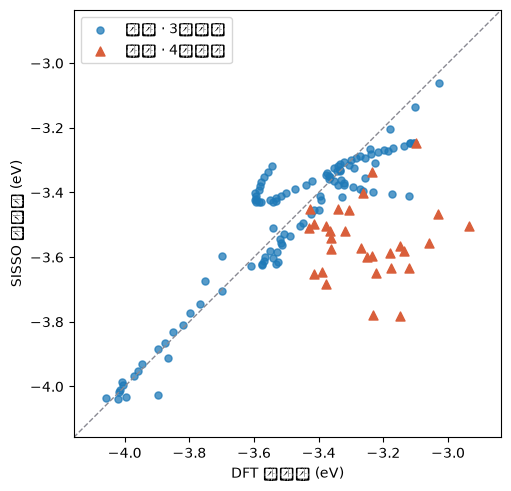

In [15]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(train.property, pred_tr, s=26, c='#1F7AB8', label='학습 · 3성분계', alpha=.75)
ax.scatter(vali.property, pred_va, s=42, c='#D95F3B', label='검증 · 4성분계', marker='^')
lo = min(train.property.min(), vali.property.min()) - .1
hi = max(train.property.max(), vali.property.max()) + .1
ax.plot([lo, hi], [lo, hi], '--', c='#8A8A93', lw=1)
ax.set_xlabel('DFT 계산값 (eV)'); ax.set_ylabel('SISSO 예측값 (eV)')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

---
## 4부 · 노브를 돌려본다

탐색을 넓히면 학습 오차는 준다. **검증 오차도 같이 줄까?**

In [16]:
결과 = []
for nx in [1, 2, 3]:
    for k in [20, 100]:
        with contextlib.redirect_stdout(io.StringIO()):
            mm = SissoModel(data=df, operators=OPS, n_expansion=nx,
                            n_term=2, k=k, device='cpu')
            rr, ee, r2_, _ = mm.fit()
        try:
            ve = rmse_f(vali.property, 수식계산(ee, vali))
        except Exception:
            ve = float('nan')
        결과.append({'rung': nx, 'k': k, '학습RMSE': round(rr, 4),
                    'R2': round(r2_, 4), '4성분계RMSE': round(ve, 4)})
pd.DataFrame(결과)

,rung,k,학습RMSE,R2,4성분계RMSE
0,1,20,0.1788,0.4782,0.1011
1,1,100,0.1788,0.4782,0.1011
2,2,20,0.0953,0.8517,0.3401
3,2,100,0.0953,0.8517,0.3401
4,3,20,0.0694,0.9213,0.3735
5,3,100,0.0566,0.9478,0.1608


### 생각해볼 것

- 학습 오차가 가장 작은 설정이 4성분계에서도 가장 좋은가?
- 그렇지 않다면, 어떤 설정을 골라야 하는가?
- 이 데이터의 특징 12개는 서로 독립인가? (힌트: 시리즈가 4개다)

---
## 정리

- 원소 물성 → 조성 가중평균 → 특징 12개 → **닫힌 수식**
- 수식이라서 새 물질에 그대로 대입할 수 있다
- 탐색을 넓히는 것과 잘 맞히는 것은 **같은 말이 아니다**